In [145]:
import pandas as pd
import numpy as np

# 先讀進模擬資料
data = pd.read_csv(r"C:\Users\USER\Desktop\碩論\程式碼\embedding_data.csv")

cols = ["X2","X3","X1"] # 針對變數標準化，後面做softmax的時候，數值才不會爆掉

data[cols] = (data[cols] - data[cols].mean()) / data[cols].std()

print(data.head())

         X2        X3        X1         Y    raw_x1    raw_x2    raw_x3
0  2.985660 -0.455945  0.902386  4.686122  0.650593  2.913862 -0.529439
1  2.183840  0.287470  0.274274  4.410815  0.162753  2.128470  0.232170
2  1.646134 -0.089969  1.195760  3.444338  0.878450  1.601779 -0.154506
3  1.815760  0.819613 -0.757854  3.378867 -0.638878  1.767930  0.777338
4  2.049346 -0.976188 -0.996825  3.135581 -0.824481  1.996731 -1.062414


In [146]:
# 為了測試模型架構，先使用第一筆資料
test = data.iloc[0,:3]
y = data.iloc[0,3]

y = np.array(y) # 為了轉tensor，所以serious要轉成array

import torch

shape = (8,1) # 投影成8維，為了方便後續的attention計算

random = torch.randn(shape, requires_grad = True) # 需要學習的地方

test = torch.tensor(test, dtype = torch.float32) # tensor毛好多，統一設定dtype = float32

test = test.reshape(1,3)

test

C:\Users\USER\AppData\Local\Temp\ipykernel_11448\2354108356.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  test = torch.tensor(test, dtype = torch.float32) # tensor毛好多，統一設定dtype = float32


tensor([[ 2.9857, -0.4559,  0.9024]])

In [147]:
y = torch.tensor(y, dtype = torch.float32)

# 將隨便猜的八維向量，根據原始的embedding縮放
# 目前是所有feature都用同一個random空間
# 可以考慮讓每個feature都各自有random空間(後續改動的地方)
E =  random @ test 

print("原始數值:")
print(test)
print("----------------------------")
print("透過這個embedding的矩陣轉換之後:")
print(random)
print("----------------------------")
print("Embedding的結果:")
print(E)

原始數值:
tensor([[ 2.9857, -0.4559,  0.9024]])
----------------------------
透過這個embedding的矩陣轉換之後:
tensor([[ 0.9577],
        [-0.8656],
        [-0.8078],
        [-0.9995],
        [-0.2661],
        [ 1.4580],
        [-1.0825],
        [-0.1393]], requires_grad=True)
----------------------------
Embedding的結果:
tensor([[ 2.8592, -0.4366,  0.8642],
        [-2.5844,  0.3947, -0.7811],
        [-2.4119,  0.3683, -0.7290],
        [-2.9840,  0.4557, -0.9019],
        [-0.7944,  0.1213, -0.2401],
        [ 4.3531, -0.6648,  1.3157],
        [-3.2319,  0.4935, -0.9768],
        [-0.4160,  0.0635, -0.1257]], grad_fn=<MmBackward0>)


In [148]:
wq_shape = (4,8) # KQ space先設定4維，反正比embedding的小

wq = torch.randn(wq_shape, requires_grad = True) # 需要學習的地方

Q = wq @ E

print("剛剛產生的embedding:")
print(E)
print("----------------------------")
print("透過這個Wq矩陣轉換之後:")
print(wq)
print("----------------------------")
print("產生的Query矩陣:")
print(Q)

剛剛產生的embedding:
tensor([[ 2.8592, -0.4366,  0.8642],
        [-2.5844,  0.3947, -0.7811],
        [-2.4119,  0.3683, -0.7290],
        [-2.9840,  0.4557, -0.9019],
        [-0.7944,  0.1213, -0.2401],
        [ 4.3531, -0.6648,  1.3157],
        [-3.2319,  0.4935, -0.9768],
        [-0.4160,  0.0635, -0.1257]], grad_fn=<MmBackward0>)
----------------------------
透過這個Wq矩陣轉換之後:
tensor([[-1.5996, -0.1715, -0.6521,  0.5556,  0.5377,  1.1657, -0.5620, -0.4787],
        [ 0.6876, -1.2520, -2.1860, -0.3111, -1.4463, -0.9986, -2.3532, -0.2112],
        [ 0.9974, -1.0398, -0.2020, -0.1303,  0.6058,  0.7818,  2.9570, -0.4383],
        [-0.7407, -0.2537, -0.7723,  1.1450,  0.1448,  0.9754, -1.0153, -0.0253]],
       requires_grad=True)
----------------------------
產生的Query矩陣:
tensor([[ 2.4477e+00, -3.7379e-01,  7.3978e-01],
        [ 1.5897e+01, -2.4277e+00,  4.8048e+00],
        [-3.7170e-02,  5.6762e-03, -1.1234e-02],
        [ 4.4063e+00, -6.7290e-01,  1.3318e+00]], grad_fn=<MmBackward0>)


In [149]:
wk_shape = (4,8)

wk = torch.randn(wq_shape, requires_grad = True) # 需要學習的地方

K = wk @ E

print("剛剛產生的embedding:")
print(E)
print("----------------------------")
print("透過這個Wk矩陣轉換之後:")
print(wk)
print("----------------------------")
print("產生的Key矩陣:")
print(K)

剛剛產生的embedding:
tensor([[ 2.8592, -0.4366,  0.8642],
        [-2.5844,  0.3947, -0.7811],
        [-2.4119,  0.3683, -0.7290],
        [-2.9840,  0.4557, -0.9019],
        [-0.7944,  0.1213, -0.2401],
        [ 4.3531, -0.6648,  1.3157],
        [-3.2319,  0.4935, -0.9768],
        [-0.4160,  0.0635, -0.1257]], grad_fn=<MmBackward0>)
----------------------------
透過這個Wk矩陣轉換之後:
tensor([[-0.4238,  0.2725,  0.8537, -0.8909, -0.4326,  0.1677, -0.2834,  2.1425],
        [-0.2890,  0.9779,  0.7333, -0.3170,  0.1445, -0.9776,  1.4276,  0.5527],
        [ 0.6813,  1.3941,  0.8516,  2.1583, -0.6621,  0.6729, -1.0047,  1.3544],
        [-0.8687,  0.4241, -0.2611, -0.4057,  0.1449, -0.8402, -1.8862, -0.5221]],
       requires_grad=True)
----------------------------
產生的Key矩陣:
tensor([[ -0.2188,   0.0334,  -0.0661],
        [-13.3903,   2.0448,  -4.0471],
        [ -4.0102,   0.6124,  -1.2120],
        [  0.8012,  -0.1224,   0.2422]], grad_fn=<MmBackward0>)


In [150]:
scores = K.T @ Q 

print("剛剛產生的Query矩陣:")
print(Q)
print("----------------------------")
print("與這個Key矩陣:")
print(K)
print("----------------------------")
print("相互的col內積之後:")
print(scores)

剛剛產生的Query矩陣:
tensor([[ 2.4477e+00, -3.7379e-01,  7.3978e-01],
        [ 1.5897e+01, -2.4277e+00,  4.8048e+00],
        [-3.7170e-02,  5.6762e-03, -1.1234e-02],
        [ 4.4063e+00, -6.7290e-01,  1.3318e+00]], grad_fn=<MmBackward0>)
----------------------------
與這個Key矩陣:
tensor([[ -0.2188,   0.0334,  -0.0661],
        [-13.3903,   2.0448,  -4.0471],
        [ -4.0102,   0.6124,  -1.2120],
        [  0.8012,  -0.1224,   0.2422]], grad_fn=<MmBackward0>)
----------------------------
相互的col內積之後:
tensor([[-209.7270,   32.0278,  -63.3879],
        [  32.0278,   -4.8910,    9.6801],
        [ -63.3879,    9.6801,  -19.1583]], grad_fn=<MmBackward0>)


In [151]:
dk = 4 # QK space的維度

scores = scores/np.sqrt(dk)
print("為了避免知運算出現數值太大的問題，")
print("矩陣同時除以sqrt(dk):")
print(scores)

為了避免知運算出現數值太大的問題，
矩陣同時除以sqrt(dk):
tensor([[-104.8635,   16.0139,  -31.6939],
        [  16.0139,   -2.4455,    4.8400],
        [ -31.6939,    4.8400,   -9.5792]], grad_fn=<DivBackward0>)


In [152]:
import torch.nn.functional as F

attn = F.softmax(scores, dim=0)

print("使用softmax，使得每個col加起來為1，")
print("表示針對哪一個變數(col)，哪些變數(row)修飾col所佔的比例，")
print("得到attention weight matrix:")
print(attn)

使用softmax，使得每個col加起來為1，
表示針對哪一個變數(col)，哪些變數(row)修飾col所佔的比例，
得到attention weight matrix:
tensor([[0.0000e+00, 9.9999e-01, 1.3599e-16],
        [1.0000e+00, 9.6201e-09, 1.0000e+00],
        [1.9088e-21, 1.4036e-05, 5.4678e-07]], grad_fn=<SoftmaxBackward0>)


In [153]:
wv_shape = (8,8) # 需要變回原本embedding的維度

wv = torch.randn(wv_shape, requires_grad = True) # 需要學習的地方

V = wv @ E

print("原始的embedding:")
print(E)
print("----------------------------------------------------")
print("經過wv的轉換後:")
print(wv)
print("----------------------------------------------------")
print("會得到V矩陣，表示如果變數(col)去修飾其他變數的embedding變化:")
print(V)

原始的embedding:
tensor([[ 2.8592, -0.4366,  0.8642],
        [-2.5844,  0.3947, -0.7811],
        [-2.4119,  0.3683, -0.7290],
        [-2.9840,  0.4557, -0.9019],
        [-0.7944,  0.1213, -0.2401],
        [ 4.3531, -0.6648,  1.3157],
        [-3.2319,  0.4935, -0.9768],
        [-0.4160,  0.0635, -0.1257]], grad_fn=<MmBackward0>)
----------------------------------------------------
經過wv的轉換後:
tensor([[ 1.8975,  0.2479, -0.6210, -1.3630,  0.1496,  2.1592,  0.8637, -0.2940],
        [-1.3581, -2.1130,  0.0415,  0.3275, -1.7558, -1.6189,  0.9562, -2.4682],
        [-2.3079,  0.8357,  0.4155, -0.3640,  1.4531,  0.2698, -1.8642,  0.8069],
        [-0.5888,  0.5295, -1.3520,  0.7060, -0.2470, -0.7230, -1.1684,  0.6437],
        [ 0.5348, -1.1689, -1.0339, -1.4138, -0.2946,  0.9563,  1.2266,  0.9826],
        [ 0.0793,  0.4601,  1.8411,  0.6720, -0.5536,  0.0704,  0.8089, -0.1171],
        [ 0.0877, -0.8066, -0.2282,  0.2913, -0.3083,  0.9482,  0.0871, -2.1396],
        [-0.9370, -0.4713,  0

In [154]:
delta_E = V @ attn

New_E = E + delta_E

print("根據得到的attention weight matrix:")
print(attn)
print("----------------------------------------------------")
print("經過每個變數的修飾(col):")
print(V)
print("----------------------------------------------------")
print("會得到應該在該變數embedding變化量(col):")
print(delta_E)


根據得到的attention weight matrix:
tensor([[0.0000e+00, 9.9999e-01, 1.3599e-16],
        [1.0000e+00, 9.6201e-09, 1.0000e+00],
        [1.9088e-21, 1.4036e-05, 5.4678e-07]], grad_fn=<SoftmaxBackward0>)
----------------------------------------------------
經過每個變數的修飾(col):
tensor([[16.9610, -2.5901,  5.1263],
        [-7.2153,  1.1019, -2.1808],
        [-2.9656,  0.4529, -0.8963],
        [-1.3407,  0.2047, -0.4052],
        [11.2865, -1.7236,  3.4112],
        [-9.2279,  1.4092, -2.7890],
        [ 6.9975, -1.0686,  2.1149],
        [-8.1752,  1.2484, -2.4709]], grad_fn=<MmBackward0>)
----------------------------------------------------
會得到應該在該變數embedding變化量(col):
tensor([[-2.5901, 16.9608, -2.5901],
        [ 1.1019, -7.2153,  1.1019],
        [ 0.4529, -2.9656,  0.4529],
        [ 0.2047, -1.3407,  0.2047],
        [-1.7236, 11.2864, -1.7236],
        [ 1.4092, -9.2278,  1.4092],
        [-1.0686,  6.9975, -1.0686],
        [ 1.2484, -8.1751,  1.2484]], grad_fn=<MmBackward0>)


In [155]:
print("因此原本的embedding:")
print(E)
print("會變成這樣:")
print(New_E)

因此原本的embedding:
tensor([[ 2.8592, -0.4366,  0.8642],
        [-2.5844,  0.3947, -0.7811],
        [-2.4119,  0.3683, -0.7290],
        [-2.9840,  0.4557, -0.9019],
        [-0.7944,  0.1213, -0.2401],
        [ 4.3531, -0.6648,  1.3157],
        [-3.2319,  0.4935, -0.9768],
        [-0.4160,  0.0635, -0.1257]], grad_fn=<MmBackward0>)
會變成這樣:
tensor([[ 0.2691, 16.5242, -1.7260],
        [-1.4826, -6.8206,  0.3207],
        [-1.9590, -2.5973, -0.2761],
        [-2.7793, -0.8850, -0.6972],
        [-2.5180, 11.4077, -1.9637],
        [ 5.7623, -9.8926,  2.7249],
        [-4.3005,  7.4910, -2.0454],
        [ 0.8325, -8.1116,  1.1227]], grad_fn=<AddBackward0>)


In [156]:
attn_before = attn.detach().clone()
print("此時的attention weight matrix:")
print(attn_before)

此時的attention weight matrix:
tensor([[0.0000e+00, 9.9999e-01, 1.3599e-16],
        [1.0000e+00, 9.6201e-09, 1.0000e+00],
        [1.9088e-21, 1.4036e-05, 5.4678e-07]])


In [157]:
# y = 0.2*x1 + 1.5*x2 + 0.8*x3 可以從匯出模擬資料.ipynb得到正確的模型模擬
y_true = data.iloc[0]["Y"] 

y_true = torch.tensor(y_true, dtype = torch.float32)

print(y_true)

tensor(4.6861)


In [158]:
import torch.nn as nn

proj = nn.Linear(8,1)

z = proj(New_E.T)

# (3,8)
# ->
# (3,1)

z = z.reshape(1,-1)

linear = nn.Linear(3,1)

y_hat = linear(z)

print(z)
print(y_hat)

tensor([[-1.4731,  2.7151, -0.7900]], grad_fn=<ViewBackward0>)
tensor([[-1.1500]], grad_fn=<AddmmBackward0>)


In [159]:
criterion = torch.nn.MSELoss()

loss = criterion(y_hat.squeeze(), y_true)

In [160]:
optimizer = torch.optim.Adam(
    [random,wq,wk,wv]+
    list(proj.parameters())+
    list(linear.parameters()),
    lr=0.001
)

optimizer.zero_grad()

loss.backward()

optimizer.step()

In [161]:
# 將隨便猜的八維向量，根據原始的embedding縮放
# 目前是所有feature都用同一個random空間
# 可以考慮讓每個feature都各自有random空間(後續改動的地方)
E =  random @ test 

wq_shape = (4,8) # KQ space先設定4維，反正比embedding的小

wq = torch.randn(wq_shape, requires_grad = True) # 需要學習的地方

Q = wq @ E

wk_shape = (4,8)

wk = torch.randn(wq_shape, requires_grad = True) # 需要學習的地方

K = wk @ E

scores = K.T @ Q 

dk = 4 # QK space的維度

scores = scores/np.sqrt(dk)

import torch.nn.functional as F

attn_after = F.softmax(scores, dim=0)

In [162]:
print("before:")
print(attn_before)

print("----------------")

print("after:")
print(attn_after)

before:
tensor([[0.0000e+00, 9.9999e-01, 1.3599e-16],
        [1.0000e+00, 9.6201e-09, 1.0000e+00],
        [1.9088e-21, 1.4036e-05, 5.4678e-07]])
----------------
after:
tensor([[1.0000e+00, 7.9377e-06, 1.0000e+00],
        [4.2592e-34, 9.9034e-01, 8.2044e-11],
        [6.3102e-21, 9.6486e-03, 7.8481e-07]], grad_fn=<SoftmaxBackward0>)


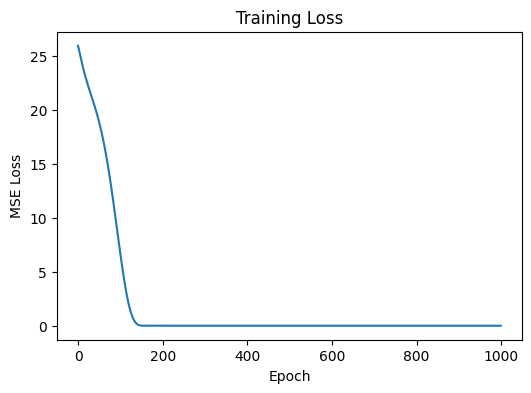

Initial Attention Matrix:
tensor([[1.0000e+00, 7.9377e-06, 1.0000e+00],
        [4.2592e-34, 9.9034e-01, 8.2044e-11],
        [6.3102e-21, 9.6486e-03, 7.8481e-07]])

Final Attention Matrix:
tensor([[1.0000e+00, 1.0570e-05, 1.0000e+00],
        [2.7998e-33, 9.8919e-01, 1.4495e-10],
        [1.9728e-20, 1.0796e-02, 1.1076e-06]])


In [163]:
import matplotlib.pyplot as plt

loss_history = []

initial_attn = None


epochs = 1000

for epoch in range(epochs):

    # =====================
    # Forward propagation
    # =====================

    random_re = random.reshape(-1,1)

    E = random_re @ test


    Q = wq @ E
    K = wk @ E

    scores = K.T @ Q
    scores = scores / (4 ** 0.5)

    attn = F.softmax(scores, dim=0)


    # 儲存第一次 attention
    if epoch == 0:
        initial_attn = attn.detach().clone()


    V = wv @ E

    delta_E = V @ attn

    New_E = E + delta_E


    # Prediction

    z = proj(New_E.T)

    z = z.reshape(1,-1)

    y_hat = linear(z)


    # Loss

    loss = (y_true - y_hat.squeeze())**2

    loss_history.append(loss.item())


    # Backpropagation

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()



# =====================
# 訓練完成後重新 forward
# 取得最後 attention
# =====================

with torch.no_grad():

    random_re = random.reshape(-1,1)

    E = random_re @ test

    Q = wq @ E

    K = wk @ E

    scores = K.T @ Q

    scores = scores / (4 ** 0.5)

    final_attn = F.softmax(scores, dim=0)



# =====================
# 畫 loss curve
# =====================

plt.figure(figsize=(6,4))

plt.plot(loss_history)

plt.xlabel("Epoch")

plt.ylabel("MSE Loss")

plt.title("Training Loss")

plt.show()



print("Initial Attention Matrix:")
print(initial_attn)


print("\nFinal Attention Matrix:")
print(final_attn)

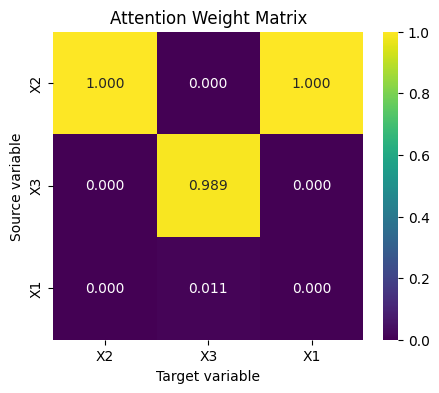

In [164]:
import seaborn as sns

# 轉成 numpy
attn_matrix = final_attn.detach().numpy()

# 設定變數名稱
labels = cols

plt.figure(figsize=(5,4))

sns.heatmap(
    attn_matrix,
    annot=True,        # 顯示數值
    fmt=".3f",         # 小數三位
    xticklabels=labels,
    yticklabels=labels,
    cmap="viridis"
)

plt.xlabel("Target variable")
plt.ylabel("Source variable")
plt.title("Attention Weight Matrix")

plt.show()

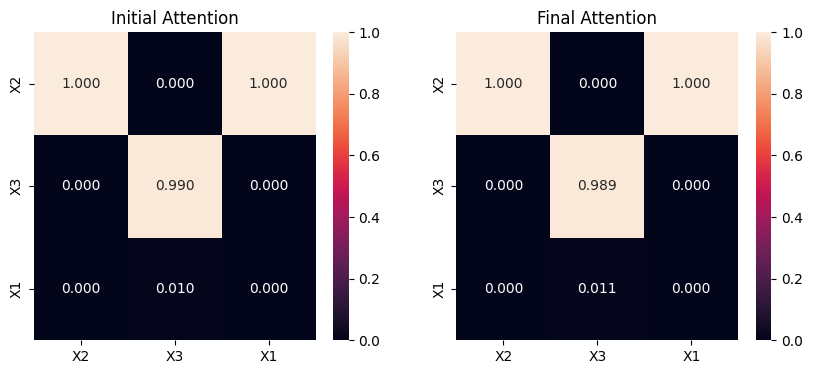

In [165]:
fig, axes = plt.subplots(1,2,figsize=(10,4))

sns.heatmap(
    initial_attn.detach().numpy(),
    annot=True,
    fmt=".3f",
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[0]
)

axes[0].set_title("Initial Attention")


sns.heatmap(
    final_attn.detach().numpy(),
    annot=True,
    fmt=".3f",
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[1]
)

axes[1].set_title("Final Attention")


plt.show()

C:\Users\USER\AppData\Local\Temp\ipykernel_11448\4015613583.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  test = torch.tensor(test, dtype = torch.float32) # tensor毛好多，統一設定dtype = float32


Initial Attention Matrix:
tensor([[0.1774, 0.3616, 0.2803],
        [0.4931, 0.3094, 0.3818],
        [0.3294, 0.3290, 0.3379]])

Final Attention Matrix:
tensor([[1.0000e+00, 5.6991e-03, 9.9755e-01],
        [4.8550e-15, 8.7436e-01, 4.7068e-05],
        [2.1655e-09, 1.1994e-01, 2.3999e-03]])


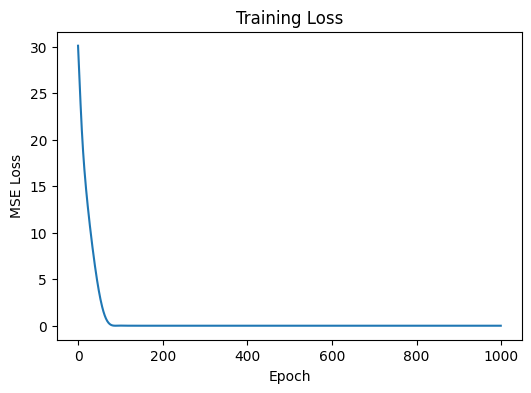

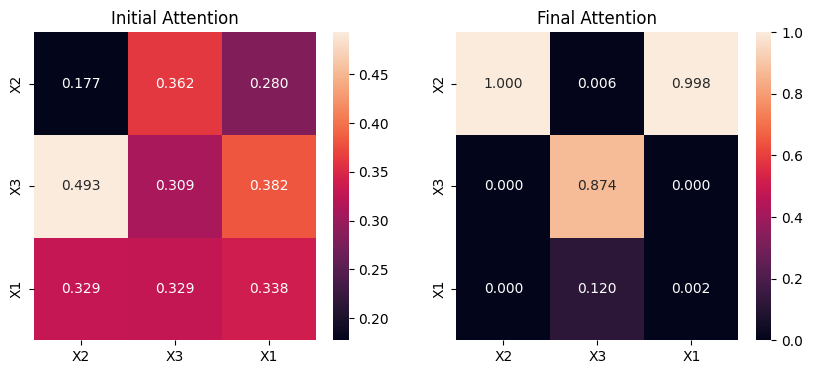

In [168]:
# 為了測試模型架構，先使用第一筆資料
test = data.iloc[0,:3]

shape = (8,1) # 投影成8維，為了方便後續的attention計算

### 定義需要學習的地方
random = torch.randn(shape, requires_grad = True) # 需要學習的地方

test = torch.tensor(test, dtype = torch.float32) # tensor毛好多，統一設定dtype = float32

test = test.reshape(1,3)

wq_shape = (4,8) # KQ space先設定4維，反正比embedding的小

wq = torch.randn(wq_shape, requires_grad = True) # 需要學習的地方

wk_shape = (4,8)

wk = torch.randn(wq_shape, requires_grad = True) # 需要學習的地方

wv_shape = (8,8) # 需要變回原本embedding的維度

wv = torch.randn(wv_shape, requires_grad = True) # 需要學習的地方

# y = 0.2*x1 + 1.5*x2 + 0.8*x3 可以從匯出模擬資料.ipynb得到正確的模型模擬
y_true = data.iloc[0]["Y"] 

y_true = torch.tensor(y_true, dtype = torch.float32)

proj = nn.Linear(8,1)

linear = nn.Linear(3,1)

optimizer = torch.optim.Adam(
    [random,wq,wk,wv]+
    list(proj.parameters())+
    list(linear.parameters()),
    lr=0.001
)

loss_history = []

initial_attn = None


epochs = 1000

for epoch in range(epochs):

    # =====================
    # Forward propagation
    # =====================

    E = random @ test


    Q = wq @ E
    K = wk @ E

    scores = K.T @ Q
    scores = scores / (4 ** 0.5)

    attn = F.softmax(scores, dim=0)


    # 儲存第一次 attention
    if epoch == 0:
        initial_attn = attn.detach().clone()


    V = wv @ E

    delta_E = V @ attn

    New_E = E + delta_E


    # Prediction

    z = proj(New_E.T)

    z = z.reshape(1,-1)

    y_hat = linear(z)


    # Loss

    loss = (y_true - y_hat.squeeze())**2

    loss_history.append(loss.item())


    # Backpropagation

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()



# =====================
# 訓練完成後重新 forward
# 取得最後 attention
# =====================

with torch.no_grad():

    random_re = random.reshape(-1,1)

    E = random_re @ test

    Q = wq @ E

    K = wk @ E

    scores = K.T @ Q

    scores = scores / (4 ** 0.5)

    final_attn = F.softmax(scores, dim=0)


### 看一下最後得到的attention weight matrix
print("Initial Attention Matrix:")
print(initial_attn)


print("\nFinal Attention Matrix:")
print(final_attn)

# =====================
# 畫 loss curve 看模型學習的趨勢
# =====================

plt.figure(figsize=(6,4))

plt.plot(loss_history)

plt.xlabel("Epoch")

plt.ylabel("MSE Loss")

plt.title("Training Loss")

plt.show()

### 可視化attention matrix
# 設定變數名稱
labels = cols

fig, axes = plt.subplots(1,2,figsize=(10,4))

sns.heatmap(
    initial_attn.detach().numpy(),
    annot=True,
    fmt=".3f",
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[0]
)

axes[0].set_title("Initial Attention")


sns.heatmap(
    final_attn.detach().numpy(),
    annot=True,
    fmt=".3f",
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[1]
)

axes[1].set_title("Final Attention")

plt.show()